In [1]:
import pandas as pd
merged_df_with_diagnosis = pd.read_csv('pathway_only_data.csv')

In [2]:
print(merged_df_with_diagnosis['Diagnosis'].value_counts())

Diagnosis
AD         141
Control    118
Name: count, dtype: int64


In [3]:
# ---------------------------------------------------------
# Filter only AD and Control diagnoses
# ---------------------------------------------------------
filtered_df = merged_df_with_diagnosis[merged_df_with_diagnosis['Diagnosis'].isin(['AD', 'Control'])]

# ---------------------------------------------------------
# Separate features (X) and labels (y)
# ---------------------------------------------------------
X = filtered_df.drop(columns=['sample_id', 'Diagnosis'])
y = filtered_df['Diagnosis'].map({'AD': 1, 'Control': 0})  # Binary classification

# ---------------------------------------------------------
# Split data into training and test sets, and scale features
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

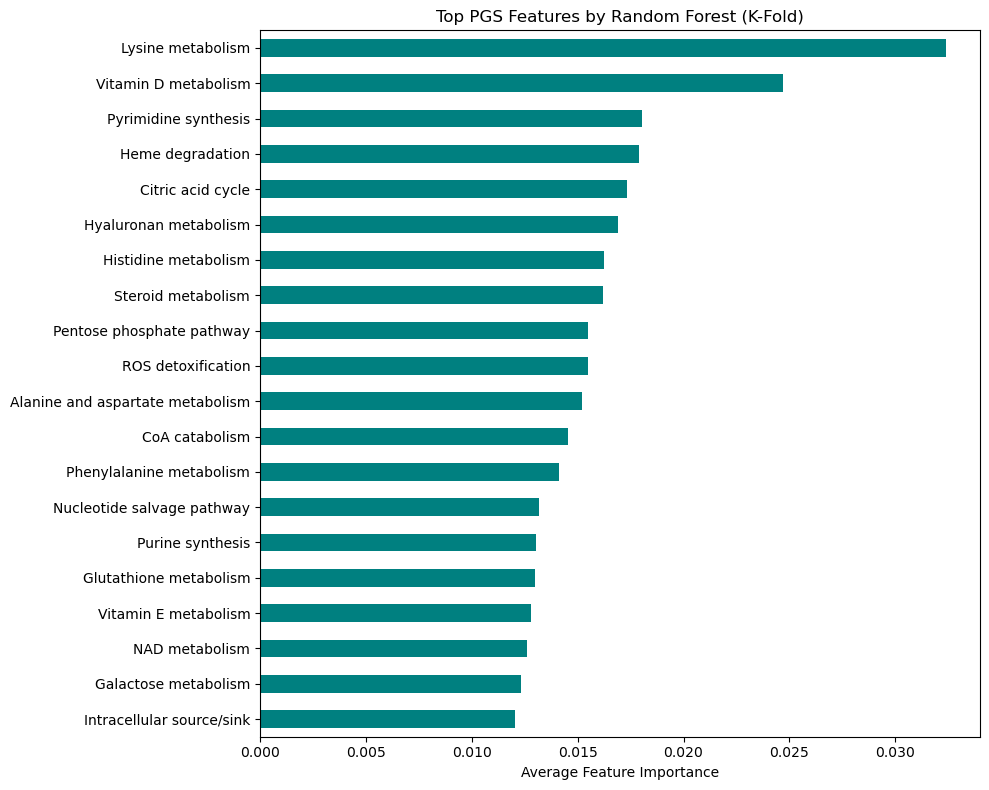

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# ---------------------------------------------------------
# Set up 5-fold cross-validation
# ---------------------------------------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------
# Initialize list to store feature importances from each fold
# ---------------------------------------------------------
feature_importances = []

# ---------------------------------------------------------
# Train Random Forest on each fold and collect feature importances
# ---------------------------------------------------------
for train_index, test_index in kf.split(X_train_scaled, y_train):
    X_fold_train = X_train_scaled[train_index]
    y_fold_train = y_train.iloc[train_index]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_fold_train, y_fold_train)

    feature_importances.append(rf.feature_importances_)

# ---------------------------------------------------------
# Calculate average feature importance across folds
# ---------------------------------------------------------
avg_importances = np.mean(feature_importances, axis=0)

# Convert to Series and sort
feat_importances = pd.Series(avg_importances, index=X.columns).sort_values(ascending=False)

# ---------------------------------------------------------
# Visualize the top 20 features
# ---------------------------------------------------------
feat_importances.head(20).plot(kind='barh', figsize=(10, 8), color='teal')
plt.title("Top PGS Features by Random Forest (K-Fold)")
plt.xlabel("Average Feature Importance")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()


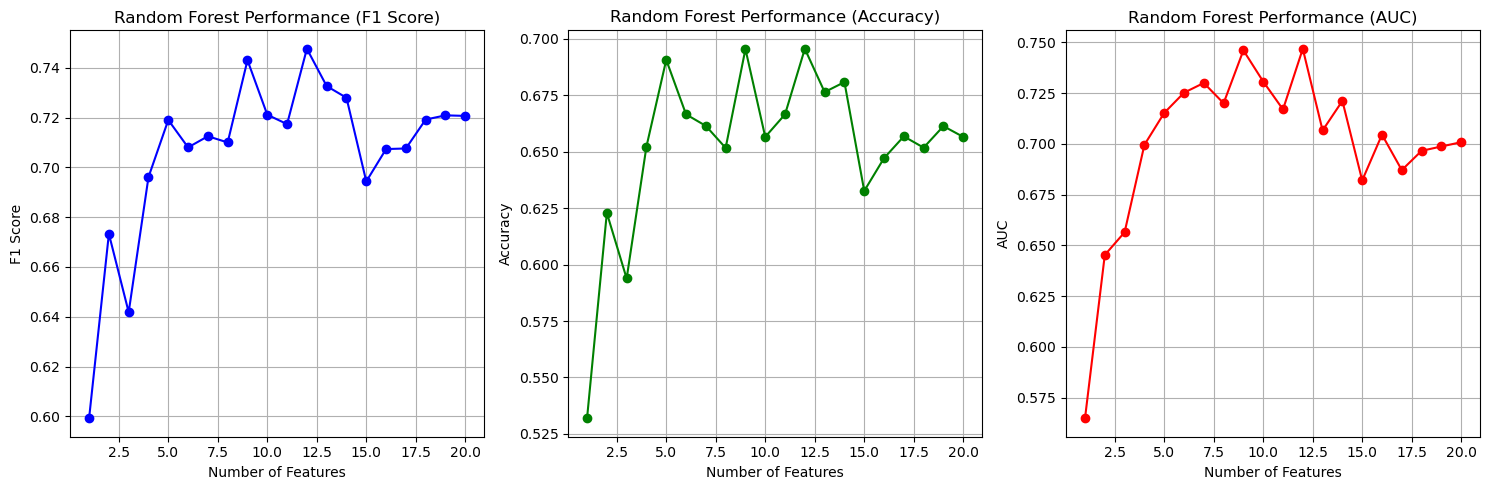

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# Set up 5-fold cross-validation
# ---------------------------------------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------
# Collect feature importances across folds
# ---------------------------------------------------------
feature_importances = []

for train_index, test_index in kf.split(X_train_scaled, y_train):
    X_fold_train = X_train_scaled[train_index]
    y_fold_train = y_train.iloc[train_index]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_fold_train, y_fold_train)

    feature_importances.append(rf.feature_importances_)

# ---------------------------------------------------------
# Compute average feature importance across folds
# ---------------------------------------------------------
avg_importances = np.mean(feature_importances, axis=0)

# Convert to Series and sort in descending order
feat_importances = pd.Series(avg_importances, index=X.columns).sort_values(ascending=False)

# ---------------------------------------------------------
# Initialize lists to store performance metrics
# ---------------------------------------------------------
f1_scores = []
accuracy_scores = []
auc_scores = []

# ---------------------------------------------------------
# Evaluate model performance using top 1, 2, ..., 20 features
# ---------------------------------------------------------
for i in range(1, 21):
    selected_features = list(feat_importances.head(i).index)
    X_selected = X_train_scaled[:, np.isin(X.columns, selected_features)]

    fold_f1 = []
    fold_accuracy = []
    fold_auc = []

    # K-Fold evaluation
    for train_index, test_index in kf.split(X_selected, y_train):
        X_fold_train = X_selected[train_index]
        y_fold_train = y_train.iloc[train_index]
        X_fold_test = X_selected[test_index]
        y_fold_test = y_train.iloc[test_index]

        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_fold_train, y_fold_train)

        # Predictions
        y_pred = rf.predict(X_fold_test)
        y_pred_prob = rf.predict_proba(X_fold_test)[:, 1]

        # Compute metrics
        fold_f1.append(f1_score(y_fold_test, y_pred))
        fold_accuracy.append(accuracy_score(y_fold_test, y_pred))
        fold_auc.append(roc_auc_score(y_fold_test, y_pred_prob))

    # Average metrics across folds
    f1_scores.append(np.mean(fold_f1))
    accuracy_scores.append(np.mean(fold_accuracy))
    auc_scores.append(np.mean(fold_auc))

# ---------------------------------------------------------
# Visualize performance metrics vs number of features
# ---------------------------------------------------------
plt.figure(figsize=(15, 5))

# F1 Score
plt.subplot(1, 3, 1)
plt.plot(range(1, 21), f1_scores, marker='o', color='blue')
plt.xlabel('Number of Features')
plt.ylabel('F1 Score')
plt.title('Random Forest Performance (F1 Score)')
plt.grid(True)

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(range(1, 21), accuracy_scores, marker='o', color='green')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance (Accuracy)')
plt.grid(True)

# AUC
plt.subplot(1, 3, 3)
plt.plot(range(1, 21), auc_scores, marker='o', color='red')
plt.xlabel('Number of Features')
plt.ylabel('AUC')
plt.title('Random Forest Performance (AUC)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------------
# Find the best scores and corresponding number of features
# ---------------------------------------------------------
feature_counts = list(range(1, 21))  # corresponds to top 1, 2, ..., 20 features

best_f1 = max(f1_scores)
best_f1_features = feature_counts[f1_scores.index(best_f1)]

best_acc = max(accuracy_scores)
best_acc_features = feature_counts[accuracy_scores.index(best_acc)]

best_auc = max(auc_scores)
best_auc_features = feature_counts[auc_scores.index(best_auc)]

# Print results in English for GitHub
print(f"Highest F1 Score: {best_f1:.4f} (Number of features: {best_f1_features})")
print(f"Highest Accuracy: {best_acc:.4f} (Number of features: {best_acc_features})")
print(f"Highest AUC Score: {best_auc:.4f} (Number of features: {best_auc_features})")

Highest F1 Score: 0.7476 (Number of features: 12)
Highest Accuracy: 0.6956 (Number of features: 12)
Highest AUC Score: 0.7468 (Number of features: 12)


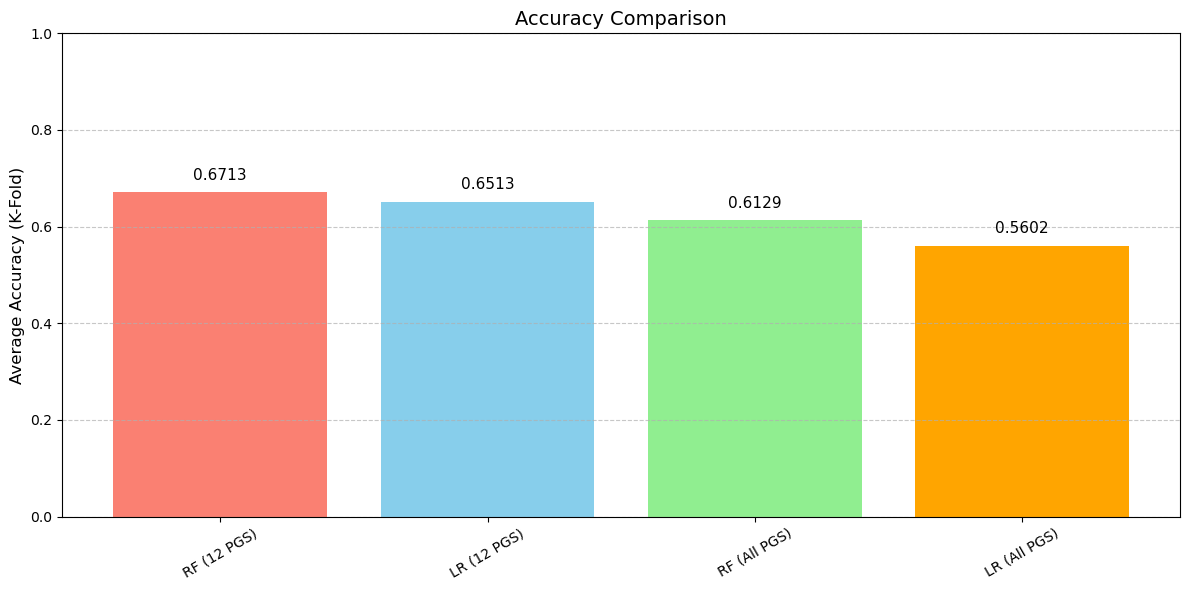

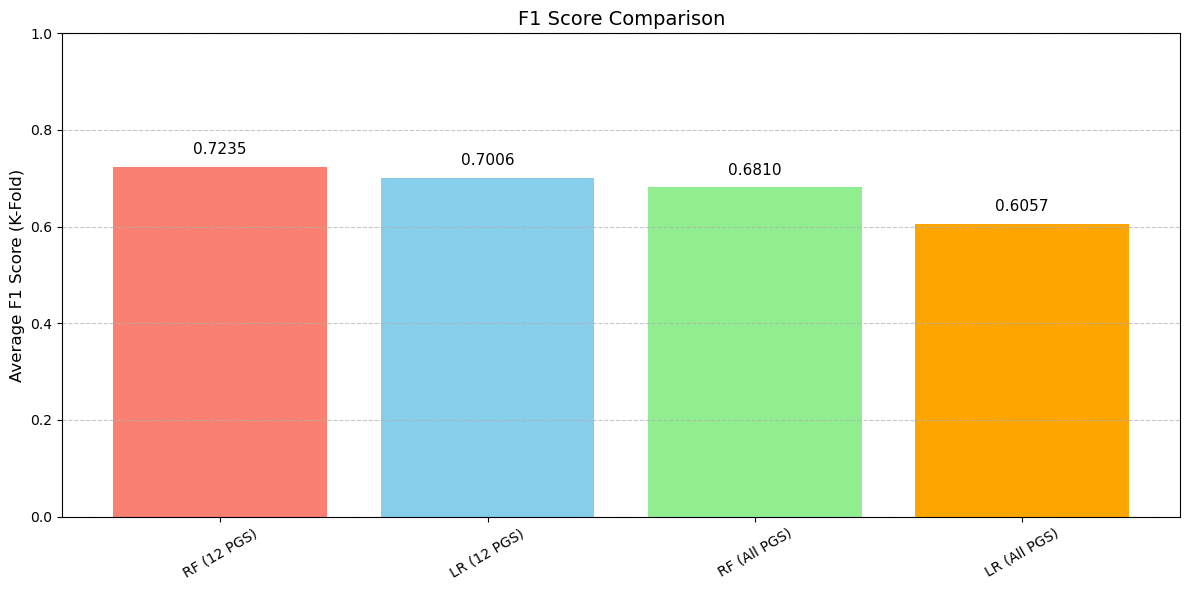

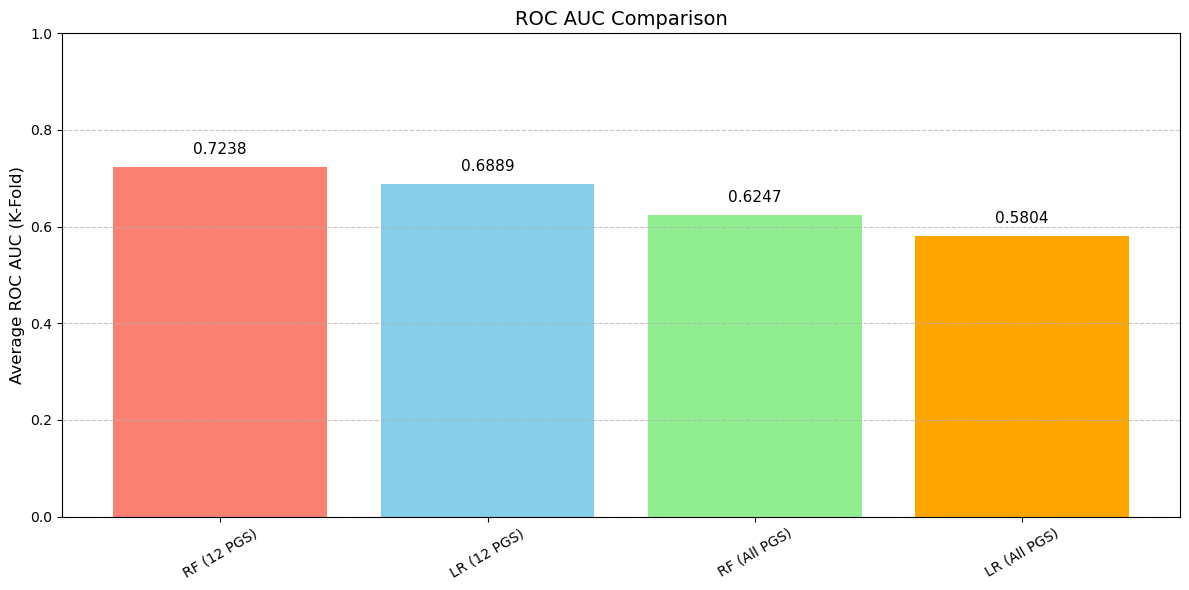

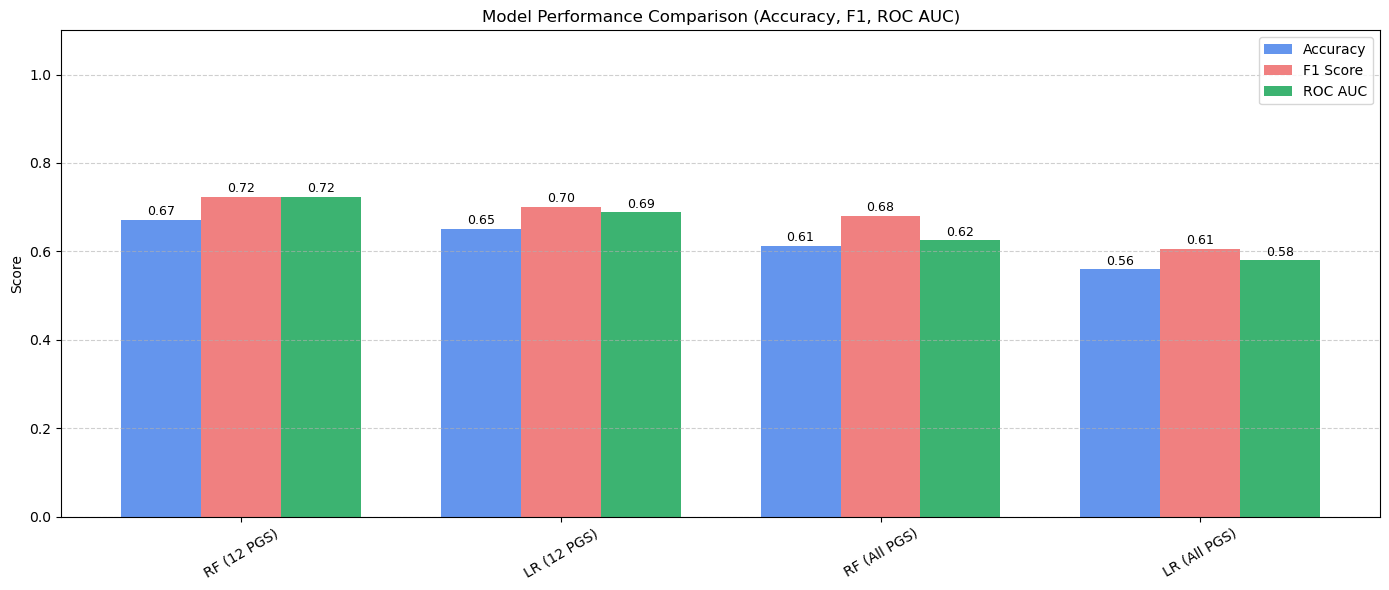

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ---------------------------------------------------------
# Select top features based on Random Forest importance
# ---------------------------------------------------------
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Initialize K-Fold cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
rf_top5_accuracies, lr_top5_accuracies = [], []
rf_all_accuracies, lr_all_accuracies = [], []

rf_top5_f1s, lr_top5_f1s = [], []
rf_all_f1s, lr_all_f1s = [], []

rf_top5_aucs, lr_top5_aucs = [], []
rf_all_aucs, lr_all_aucs = [], []

# ---------------------------------------------------------
# Train and evaluate models using K-Fold CV
# Compare top 5 PGS features vs all PGS features
# ---------------------------------------------------------
for train_index, test_index in kf.split(X_train_scaled, y_train):
    X_train_fold, X_test_fold = X_train_scaled[train_index], X_train_scaled[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Use top 5 PGS features
    X_train_top5 = X_train_fold[:, top_5_indices]
    X_test_top5 = X_test_fold[:, top_5_indices]

    # Random Forest - Top 5
    rf_top5 = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_top5.fit(X_train_top5, y_train_fold)
    rf_top5_pred = rf_top5.predict(X_test_top5)
    rf_top5_accuracies.append(accuracy_score(y_test_fold, rf_top5_pred))
    rf_top5_f1s.append(f1_score(y_test_fold, rf_top5_pred))
    rf_top5_aucs.append(roc_auc_score(y_test_fold, rf_top5.predict_proba(X_test_top5)[:, 1]))

    # Logistic Regression - Top 5
    lr_top5 = LogisticRegression(random_state=42, max_iter=1000)
    lr_top5.fit(X_train_top5, y_train_fold)
    lr_top5_pred = lr_top5.predict(X_test_top5)
    lr_top5_accuracies.append(accuracy_score(y_test_fold, lr_top5_pred))
    lr_top5_f1s.append(f1_score(y_test_fold, lr_top5_pred))
    lr_top5_aucs.append(roc_auc_score(y_test_fold, lr_top5.predict_proba(X_test_top5)[:, 1]))

    # Random Forest - All features
    rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_all.fit(X_train_fold, y_train_fold)
    rf_all_pred = rf_all.predict(X_test_fold)
    rf_all_accuracies.append(accuracy_score(y_test_fold, rf_all_pred))
    rf_all_f1s.append(f1_score(y_test_fold, rf_all_pred))
    rf_all_aucs.append(roc_auc_score(y_test_fold, rf_all.predict_proba(X_test_fold)[:, 1]))

    # Logistic Regression - All features
    lr_all = LogisticRegression(random_state=42, max_iter=1000)
    lr_all.fit(X_train_fold, y_train_fold)
    lr_all_pred = lr_all.predict(X_test_fold)
    lr_all_accuracies.append(accuracy_score(y_test_fold, lr_all_pred))
    lr_all_f1s.append(f1_score(y_test_fold, lr_all_pred))
    lr_all_aucs.append(roc_auc_score(y_test_fold, lr_all.predict_proba(X_test_fold)[:, 1]))

# ---------------------------------------------------------
# Compute average metrics
# ---------------------------------------------------------
avg_accuracies = [
    np.mean(rf_top5_accuracies),
    np.mean(lr_top5_accuracies),
    np.mean(rf_all_accuracies),
    np.mean(lr_all_accuracies)
]

avg_f1s = [
    np.mean(rf_top5_f1s),
    np.mean(lr_top5_f1s),
    np.mean(rf_all_f1s),
    np.mean(lr_all_f1s)
]

avg_aucs = [
    np.mean(rf_top5_aucs),
    np.mean(lr_top5_aucs),
    np.mean(rf_all_aucs),
    np.mean(lr_all_aucs)
]

# ---------------------------------------------------------
# Plot Accuracy comparison
# ---------------------------------------------------------
models = [f'RF ({best_acc_features} PGS)', f'LR ({best_acc_features} PGS)', 'RF (All PGS)', 'LR (All PGS)']
colors = ['salmon', 'skyblue', 'lightgreen', 'orange']

plt.figure(figsize=(12, 6))
bars = plt.bar(models, avg_accuracies, color=colors)
plt.ylabel('Average Accuracy (K-Fold)', fontsize=12)
plt.title('Accuracy Comparison', fontsize=14)
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, avg_accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot F1 Score comparison
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
bars = plt.bar(models, avg_f1s, color=colors)
plt.ylabel('Average F1 Score (K-Fold)', fontsize=12)
plt.title('F1 Score Comparison', fontsize=14)
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, f1 in zip(bars, avg_f1s):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot ROC AUC comparison
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
bars = plt.bar(models, avg_aucs, color=colors)
plt.ylabel('Average ROC AUC (K-Fold)', fontsize=12)
plt.title('ROC AUC Comparison', fontsize=14)
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, auc in zip(bars, avg_aucs):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Combined plot for Accuracy, F1, ROC AUC
# ---------------------------------------------------------
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, avg_accuracies, width=width, label='Accuracy', color='cornflowerblue')
plt.bar(x, avg_f1s, width=width, label='F1 Score', color='lightcoral')
plt.bar(x + width, avg_aucs, width=width, label='ROC AUC', color='mediumseagreen')

# Add text labels on top of each bar
for i in range(len(models)):
    plt.text(x[i] - width, avg_accuracies[i] + 0.01, f'{avg_accuracies[i]:.2f}', ha='center', fontsize=9)
    plt.text(x[i], avg_f1s[i] + 0.01, f'{avg_f1s[i]:.2f}', ha='center', fontsize=9)
    plt.text(x[i] + width, avg_aucs[i] + 0.01, f'{avg_aucs[i]:.2f}', ha='center', fontsize=9)

plt.xticks(x, models, rotation=30)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Performance Comparison (Accuracy, F1, ROC AUC)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('combined_scores_graph.png', format='png')
plt.show()

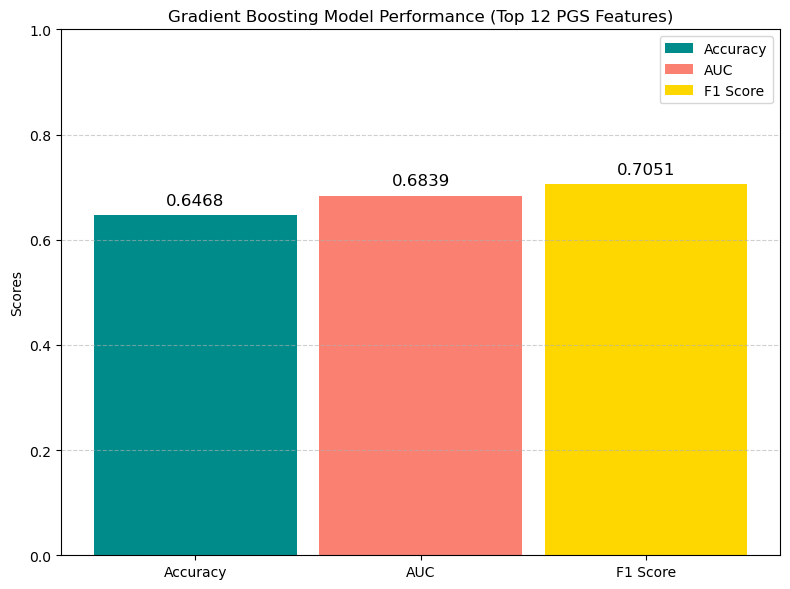

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# Select the top 5 important PGS features
# ---------------------------------------------------------
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Create dataset with only top 5 features
X_top5 = X_train_scaled[:, top_5_indices]
y = y_train

# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# K-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb_accuracies = []
gb_aucs = []
gb_f1s = []

# ---------------------------------------------------------
# Perform K-Fold evaluation
# ---------------------------------------------------------
for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    gb_model.fit(X_train_fold, y_train_fold)
    y_pred = gb_model.predict(X_test_fold)
    y_pred_prob = gb_model.predict_proba(X_test_fold)[:, 1]  # Probabilities for AUC

    # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred)
    auc = roc_auc_score(label_binarize(y_test_fold, classes=[0, 1]), y_pred_prob)
    f1 = f1_score(y_test_fold, y_pred)

    gb_accuracies.append(acc)
    gb_aucs.append(auc)
    gb_f1s.append(f1)

# ---------------------------------------------------------
# Compute average metrics
# ---------------------------------------------------------
mean_gb_acc = np.mean(gb_accuracies)
mean_gb_auc = np.mean(gb_aucs)
mean_gb_f1 = np.mean(gb_f1s)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.9  # Bar width

# Draw bars
ax.bar(0, mean_gb_acc, width, color='darkcyan', label='Accuracy')
ax.bar(1, mean_gb_auc, width, color='salmon', label='AUC')
ax.bar(2, mean_gb_f1, width, color='gold', label='F1 Score')

# Graph details
ax.set_ylabel('Scores')
ax.set_title(f'Gradient Boosting Model Performance (Top {best_acc_features} PGS Features)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Accuracy', 'AUC', 'F1 Score'])
ax.set_ylim([0, 1])
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
ax.text(0, mean_gb_acc + 0.02, f"{mean_gb_acc:.4f}", ha='center', fontsize=12)
ax.text(1, mean_gb_auc + 0.02, f"{mean_gb_auc:.4f}", ha='center', fontsize=12)
ax.text(2, mean_gb_f1 + 0.02, f"{mean_gb_f1:.4f}", ha='center', fontsize=12)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

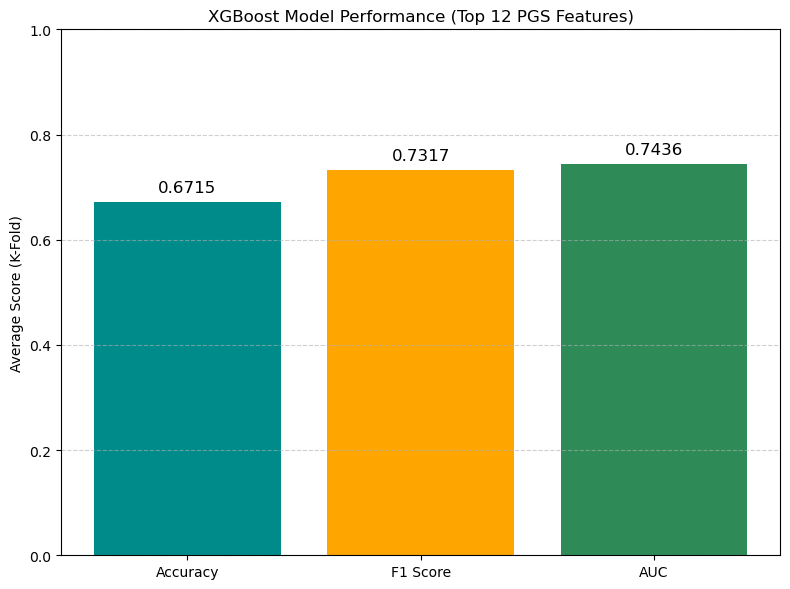

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ---------------------------------------------------------
# Select the top 5 important PGS features
# ---------------------------------------------------------
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Create dataset with only top 5 features
X_top5 = X_train_scaled[:, top_5_indices]
y = y_train

# Initialize XGBoost model (without use_label_encoder)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'  # Required for newer versions
)

# K-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_accuracies = []
xgb_f1_scores = []
xgb_auc_scores = []

# ---------------------------------------------------------
# Perform K-Fold evaluation
# ---------------------------------------------------------
for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    xgb_model.fit(X_train_fold, y_train_fold)
    y_pred = xgb_model.predict(X_test_fold)
    y_prob = xgb_model.predict_proba(X_test_fold)[:, 1]  # Probabilities for AUC

    # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)
    auc = roc_auc_score(y_test_fold, y_prob)

    xgb_accuracies.append(acc)
    xgb_f1_scores.append(f1)
    xgb_auc_scores.append(auc)

# ---------------------------------------------------------
# Compute average metrics
# ---------------------------------------------------------
mean_xgb_acc = np.mean(xgb_accuracies)
mean_xgb_f1 = np.mean(xgb_f1_scores)
mean_xgb_auc = np.mean(xgb_auc_scores)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

metrics = ['Accuracy', 'F1 Score', 'AUC']
values = [mean_xgb_acc, mean_xgb_f1, mean_xgb_auc]
colors = ['darkcyan', 'orange', 'seagreen']

ax.bar(metrics, values, color=colors)
ax.set_ylim([0, 1])
ax.set_ylabel('Average Score (K-Fold)')
ax.set_title(f'XGBoost Model Performance (Top {best_acc_features} PGS Features)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

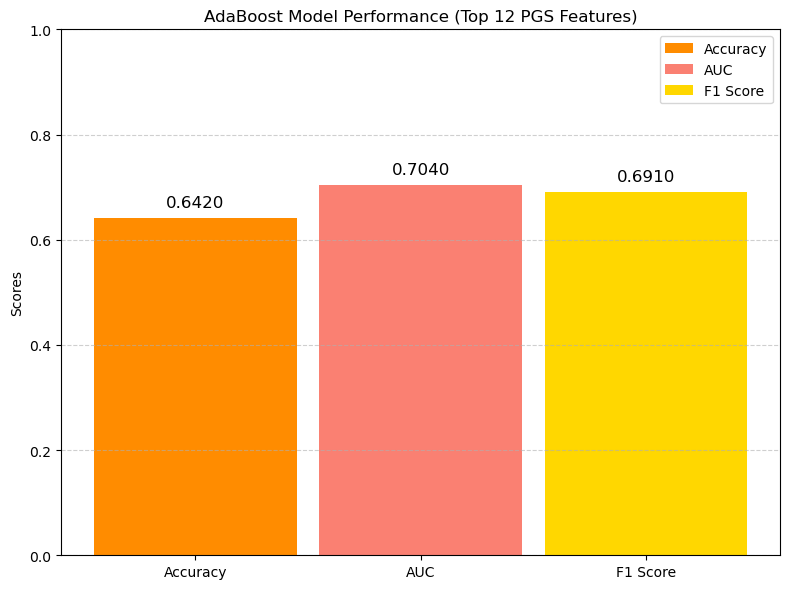

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# Select the top 5 most important PGS features
# ---------------------------------------------------------
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Create dataset using only top 5 features
X_top5 = X_train_scaled[:, top_5_indices]
y = y_train

# Initialize AdaBoost classifier
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# K-Fold Cross Validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ada_accuracies = []
ada_aucs = []
ada_f1s = []

# ---------------------------------------------------------
# K-Fold evaluation
# ---------------------------------------------------------
for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Fit model
    ada_model.fit(X_train_fold, y_train_fold)

    # Predict labels and probabilities
    y_pred = ada_model.predict(X_test_fold)
    y_pred_prob = ada_model.predict_proba(X_test_fold)[:, 1]  # Probabilities for AUC

    # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred)
    auc = roc_auc_score(label_binarize(y_test_fold, classes=[0, 1]), y_pred_prob)
    f1 = f1_score(y_test_fold, y_pred)

    ada_accuracies.append(acc)
    ada_aucs.append(auc)
    ada_f1s.append(f1)

# ---------------------------------------------------------
# Average metrics
# ---------------------------------------------------------
mean_ada_acc = np.mean(ada_accuracies)
mean_ada_auc = np.mean(ada_aucs)
mean_ada_f1 = np.mean(ada_f1s)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.9  # Bar width

# Plot bars
ax.bar(0, mean_ada_acc, width, color='darkorange', label='Accuracy')
ax.bar(1, mean_ada_auc, width, color='salmon', label='AUC')
ax.bar(2, mean_ada_f1, width, color='gold', label='F1 Score')

# Plot details
ax.set_ylabel('Scores')
ax.set_title(f'AdaBoost Model Performance (Top {best_acc_features} PGS Features)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Accuracy', 'AUC', 'F1 Score'])
ax.set_ylim([0, 1])
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
ax.text(0, mean_ada_acc + 0.02, f"{mean_ada_acc:.4f}", ha='center', fontsize=12)
ax.text(1, mean_ada_auc + 0.02, f"{mean_ada_auc:.4f}", ha='center', fontsize=12)
ax.text(2, mean_ada_f1 + 0.02, f"{mean_ada_f1:.4f}", ha='center', fontsize=12)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()


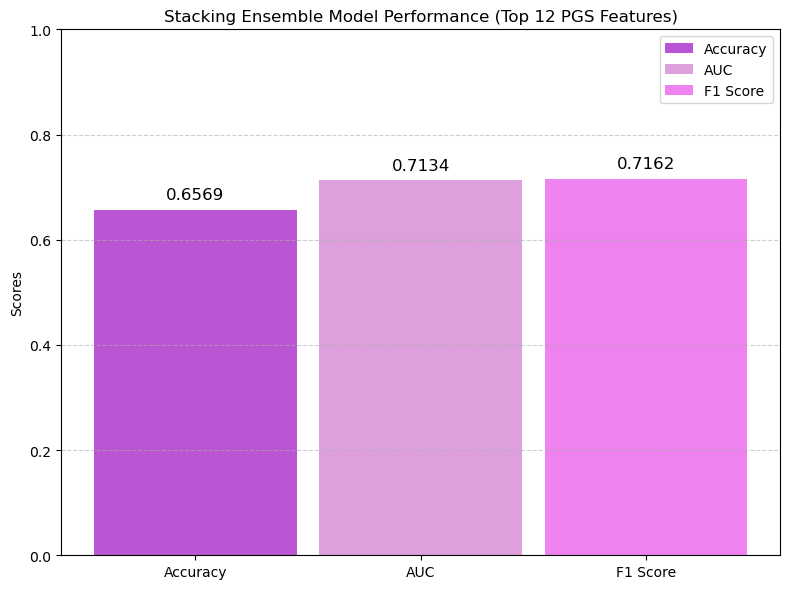

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# Select top 5 important PGS features
# ---------------------------------------------------------
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Create dataset with only top 5 features
X_top5 = X_train_scaled[:, top_5_indices]
y = y_train

# ---------------------------------------------------------
# Define Stacking ensemble with base learners
# ---------------------------------------------------------
base_learners = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier())
]

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=False
)

# ---------------------------------------------------------
# K-Fold Cross-Validation
# ---------------------------------------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stack_accuracies = []
stack_aucs = []
stack_f1s = []

for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Fit model
    stack_model.fit(X_train_fold, y_train_fold)
    
    # Predictions and probabilities
    y_pred = stack_model.predict(X_test_fold)
    y_pred_prob = stack_model.predict_proba(X_test_fold)[:, 1]  # For AUC

    # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred)
    auc = roc_auc_score(label_binarize(y_test_fold, classes=[0, 1]), y_pred_prob)
    f1 = f1_score(y_test_fold, y_pred)

    stack_accuracies.append(acc)
    stack_aucs.append(auc)
    stack_f1s.append(f1)

# ---------------------------------------------------------
# Compute average metrics
# ---------------------------------------------------------
mean_stack_acc = np.mean(stack_accuracies)
mean_stack_auc = np.mean(stack_aucs)
mean_stack_f1 = np.mean(stack_f1s)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.9  # Bar width

# Plot metrics
ax.bar(0, mean_stack_acc, width, color='mediumorchid', label='Accuracy')
ax.bar(1, mean_stack_auc, width, color='plum', label='AUC')
ax.bar(2, mean_stack_f1, width, color='violet', label='F1 Score')

# Plot details
ax.set_ylabel('Scores')
ax.set_title(f'Stacking Ensemble Model Performance (Top {best_acc_features} PGS Features)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Accuracy', 'AUC', 'F1 Score'])
ax.set_ylim([0, 1])
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
ax.text(0, mean_stack_acc + 0.02, f"{mean_stack_acc:.4f}", ha='center', fontsize=12)
ax.text(1, mean_stack_auc + 0.02, f"{mean_stack_auc:.4f}", ha='center', fontsize=12)
ax.text(2, mean_stack_f1 + 0.02, f"{mean_stack_f1:.4f}", ha='center', fontsize=12)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

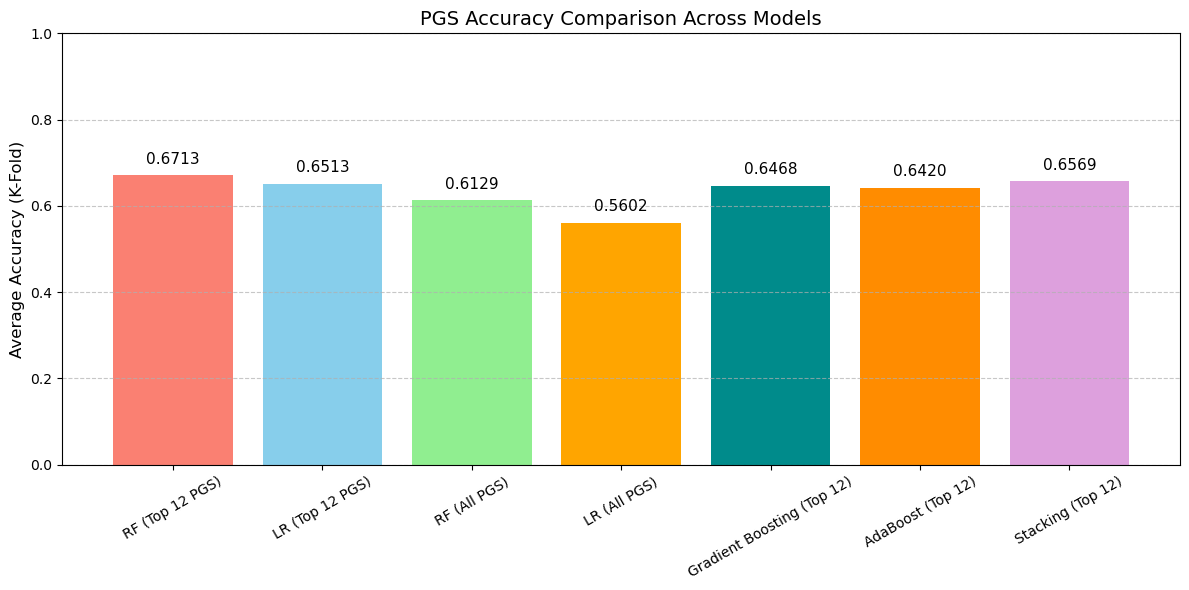

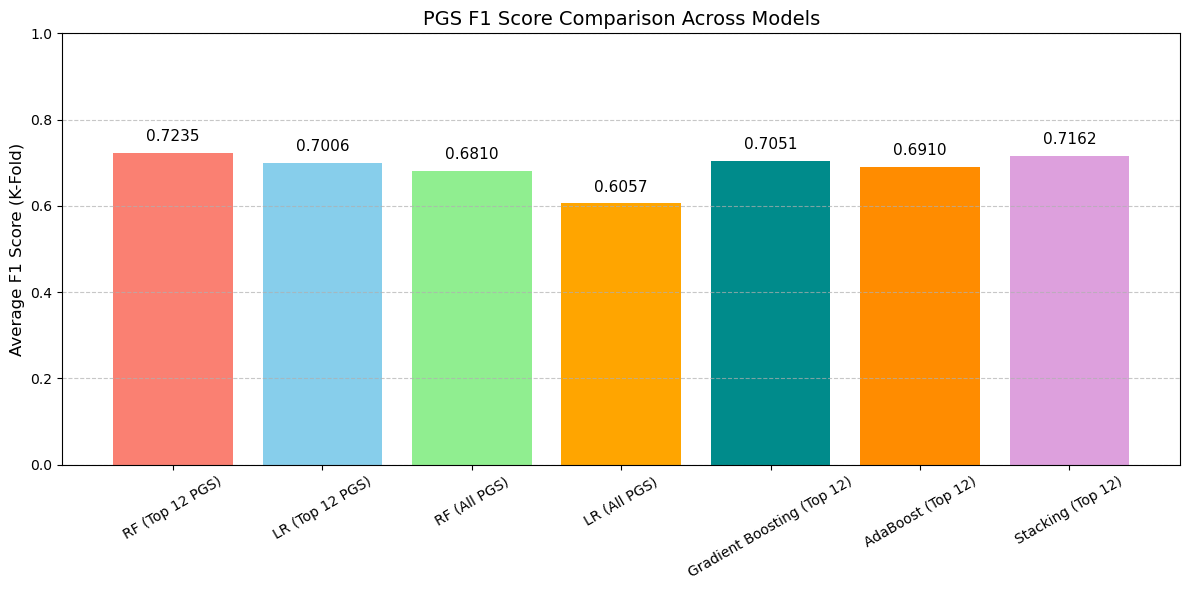

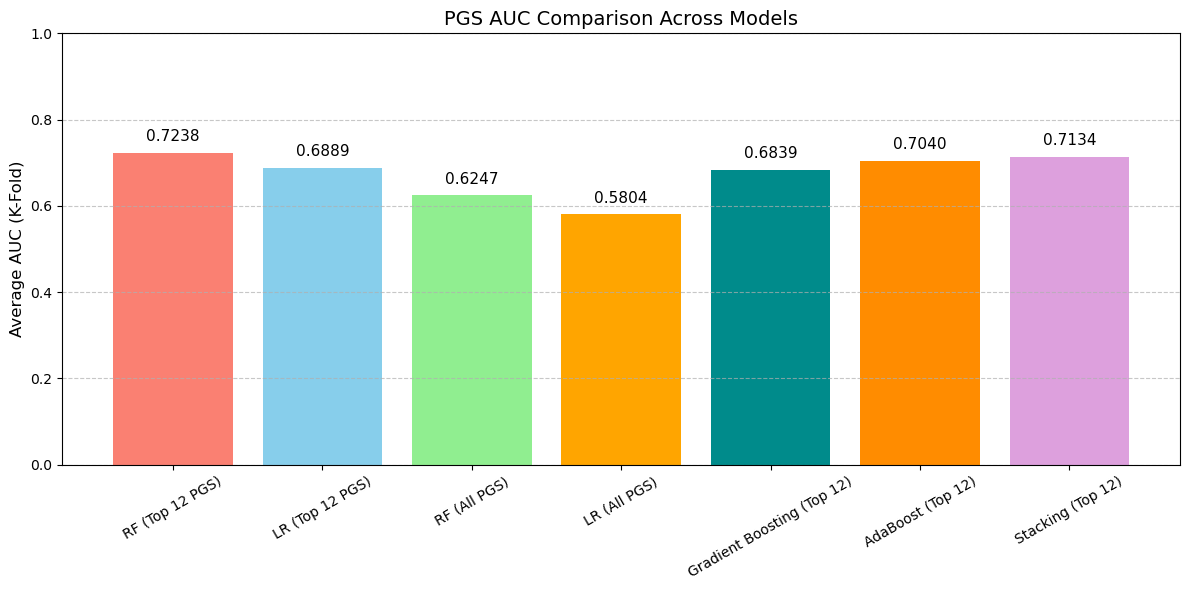

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Average scores for all models
# ---------------------------------------------------------
avg_accuracies = [
    np.mean(rf_top5_accuracies),
    np.mean(lr_top5_accuracies),
    np.mean(rf_all_accuracies),
    np.mean(lr_all_accuracies),
    mean_gb_acc,
    mean_ada_acc,
    mean_stack_acc
]

avg_f1_scores = [
    np.mean(rf_top5_f1s),
    np.mean(lr_top5_f1s),
    np.mean(rf_all_f1s),
    np.mean(lr_all_f1s),
    mean_gb_f1,
    mean_ada_f1,
    mean_stack_f1
]

avg_auc_scores = [
    np.mean(rf_top5_aucs),
    np.mean(lr_top5_aucs),
    np.mean(rf_all_aucs),
    np.mean(lr_all_aucs),
    mean_gb_auc,
    mean_ada_auc,
    mean_stack_auc
]

model_names = [
    f'RF (Top {best_acc_features} PGS)',
    f'LR (Top {best_acc_features} PGS)',
    'RF (All PGS)',
    'LR (All PGS)',
    f'Gradient Boosting (Top {best_acc_features})',
    f'AdaBoost (Top {best_acc_features})',
    f'Stacking (Top {best_acc_features})'
]

colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'darkcyan', 'darkorange', 'plum']

# ---------------------------------------------------------
# Function to plot bar charts for a metric
# ---------------------------------------------------------
def plot_metric(values, ylabel, title):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(model_names, values, color=colors)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.ylim([0, 1])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar, val in zip(bars, values):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)
    
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Plot all metrics
# ---------------------------------------------------------
plot_metric(avg_accuracies, 'Average Accuracy (K-Fold)', 'PGS Accuracy Comparison Across Models')
plot_metric(avg_f1_scores, 'Average F1 Score (K-Fold)', 'PGS F1 Score Comparison Across Models')
plot_metric(avg_auc_scores, 'Average AUC (K-Fold)', 'PGS AUC Comparison Across Models')

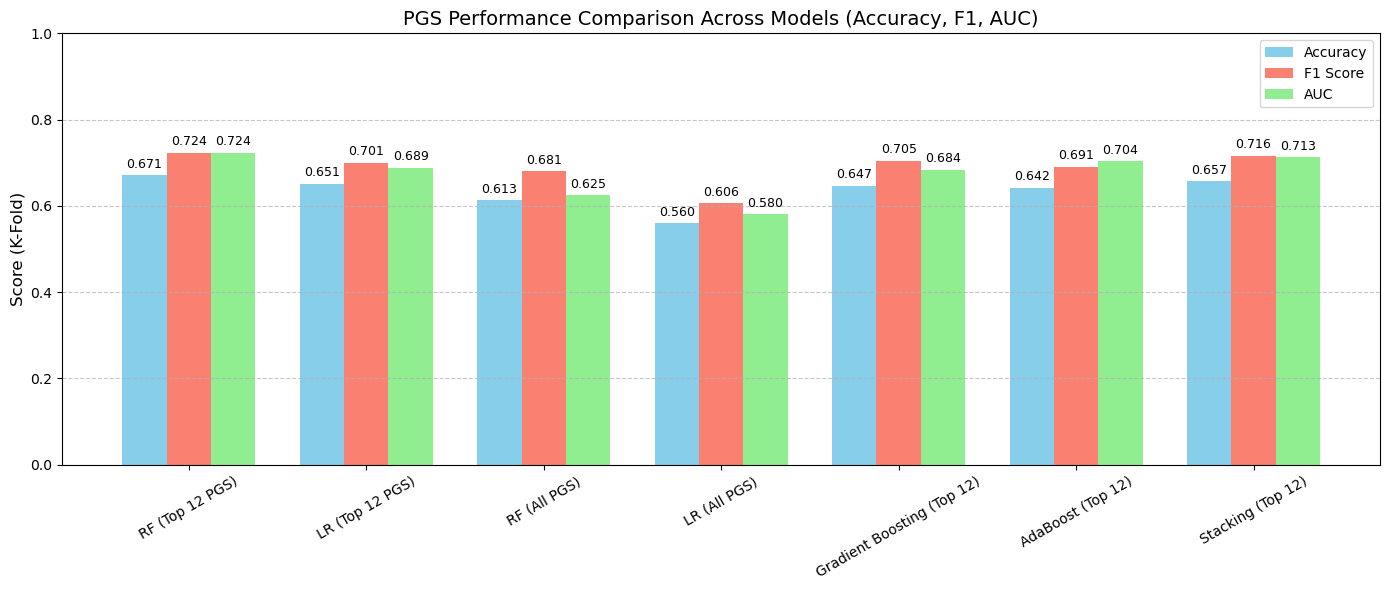

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Average metrics from your models
avg_accuracies = [
    np.mean(rf_top5_accuracies),
    np.mean(lr_top5_accuracies),
    np.mean(rf_all_accuracies),
    np.mean(lr_all_accuracies),
    mean_gb_acc,
    mean_ada_acc,
    np.mean(stack_accuracies)
]

avg_f1_scores = [
    np.mean(rf_top5_f1s),
    np.mean(lr_top5_f1s),
    np.mean(rf_all_f1s),
    np.mean(lr_all_f1s),
    mean_gb_f1,
    np.mean(ada_f1s),
    np.mean(stack_f1s)
]

avg_auc_scores = [
    np.mean(rf_top5_aucs),
    np.mean(lr_top5_aucs),
    np.mean(rf_all_aucs),
    np.mean(lr_all_aucs),
    mean_gb_auc,
    np.mean(ada_aucs),
    mean_stack_auc
]

# Model names
model_names = [
    f'RF (Top {best_acc_features} PGS)',
    f'LR (Top {best_acc_features} PGS)',
    'RF (All PGS)',
    'LR (All PGS)',
    f'Gradient Boosting (Top {best_acc_features})',
    f'AdaBoost (Top {best_acc_features})',
    f'Stacking (Top {best_acc_features})'
]

# X positions and bar width
x = np.arange(len(model_names))
width = 0.25  # width of the bars

plt.figure(figsize=(14, 6))

# Plot each metric
bars1 = plt.bar(x - width, avg_accuracies, width, label='Accuracy', color='skyblue')
bars2 = plt.bar(x, avg_f1_scores, width, label='F1 Score', color='salmon')
bars3 = plt.bar(x + width, avg_auc_scores, width, label='AUC', color='lightgreen')

# Labels and title
plt.ylabel('Score (K-Fold)', fontsize=12)
plt.title('PGS Performance Comparison Across Models (Accuracy, F1, AUC)', fontsize=14)
plt.xticks(x, model_names, rotation=30)
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Function to add value labels above bars
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.show()

In [14]:
import numpy as np

# -------------------------------
# Accuracy: mean and standard deviation across K-Fold
# -------------------------------
acc_means = [
    np.mean(rf_top5_accuracies),
    np.mean(lr_top5_accuracies),
    np.mean(rf_all_accuracies),
    np.mean(lr_all_accuracies),
    mean_gb_acc,
    mean_ada_acc,
    np.mean(stack_accuracies)
]

acc_stds = [
    np.std(rf_top5_accuracies),
    np.std(lr_top5_accuracies),
    np.std(rf_all_accuracies),
    np.std(lr_all_accuracies),
    np.std(gb_accuracies),
    np.std(ada_accuracies),
    np.std(stack_accuracies)
]

# -------------------------------
# F1 Score: mean and standard deviation across K-Fold
# -------------------------------
f1_means = [
    np.mean(rf_top5_f1s),
    np.mean(lr_top5_f1s),
    np.mean(rf_all_f1s),
    np.mean(lr_all_f1s),
    mean_gb_f1,
    np.mean(ada_f1s),
    np.mean(stack_f1s)
]

f1_stds = [
    np.std(rf_top5_f1s),
    np.std(lr_top5_f1s),
    np.std(rf_all_f1s),
    np.std(lr_all_f1s),
    np.std(gb_f1s),
    np.std(ada_f1s),
    np.std(stack_f1s)
]

# -------------------------------
# AUC: mean and standard deviation across K-Fold
# -------------------------------
auc_means = [
    np.mean(rf_top5_aucs),
    np.mean(lr_top5_aucs),
    np.mean(rf_all_aucs),
    np.mean(lr_all_aucs),
    mean_gb_auc,
    np.mean(ada_aucs),
    mean_stack_auc
]

auc_stds = [
    np.std(rf_top5_aucs),
    np.std(lr_top5_aucs),
    np.std(rf_all_aucs),
    np.std(lr_all_aucs),
    np.std(gb_aucs),
    np.std(ada_aucs),
    np.std(stack_aucs)
]

# -------------------------------
# Model names
# -------------------------------
model_names = [
    f'RF (Top {best_acc_features} PGS)',
    f'LR (Top {best_acc_features} PGS)',
    'RF (All PGS)',
    'LR (All PGS)',
    f'Gradient Boosting (Top {best_acc_features})',
    f'AdaBoost (Top {best_acc_features})',
    f'Stacking (Top {best_acc_features})'
]

# -------------------------------
# Print the summary table with mean ± std
# -------------------------------
print("Model                                Accuracy (mean ± std)\tF1 Score (mean ± std)\tAUC (mean ± std)")
print("-" * 120)

for name, acc_m, acc_s, f1_m, f1_s, auc_m, auc_s in zip(
    model_names, acc_means, acc_stds, f1_means, f1_stds, auc_means, auc_stds
):
    print(f"{name:<40} {acc_m:.4f} ± {acc_s:.4f}\t{f1_m:.4f} ± {f1_s:.4f}\t{auc_m:.4f} ± {auc_s:.4f}")

Model                                Accuracy (mean ± std)	F1 Score (mean ± std)	AUC (mean ± std)
------------------------------------------------------------------------------------------------------------------------
RF (Top 12 PGS)                          0.6713 ± 0.0266	0.7235 ± 0.0128	0.7238 ± 0.0422
LR (Top 12 PGS)                          0.6513 ± 0.0730	0.7006 ± 0.0750	0.6889 ± 0.0829
RF (All PGS)                             0.6129 ± 0.0982	0.6810 ± 0.0724	0.6247 ± 0.0878
LR (All PGS)                             0.5602 ± 0.0742	0.6057 ± 0.0592	0.5804 ± 0.0875
Gradient Boosting (Top 12)               0.6468 ± 0.0717	0.7051 ± 0.0553	0.6839 ± 0.1006
AdaBoost (Top 12)                        0.6420 ± 0.0520	0.6910 ± 0.0461	0.7040 ± 0.0607
Stacking (Top 12)                        0.6569 ± 0.0359	0.7162 ± 0.0340	0.7134 ± 0.0613
